Linear Regression

In [ ]:
import pandas as pd
import numpy as np

X = [31,23,36,38,20,40,28,14,50]
Y = [182,139,195,114,168,175,185,127,102]

df = pd.DataFrame({
    'X': X,
    'Y': Y
})

# Mean values
X_bar = df['X'].mean()
Y_bar = df['Y'].mean()

df['X-Xbar'] = df['X'] - X_bar
df['Y-Ybar'] = df['Y'] - Y_bar

df['(X-Xbar)*(Y-Ybar)'] = df['X-Xbar'] * df['Y-Ybar']
df['(X-Xbar)^2'] = df['X-Xbar'] ** 2

# Slope (m) and Intercept (c)
m = df['(X-Xbar)*(Y-Ybar)'].sum() / df['(X-Xbar)^2'].sum()
c = Y_bar - m * X_bar

# Predicted Y
df['Y_pred'] = m * df['X'] + c

# Errors
df['Error'] = df['Y'] - df['Y_pred']
df['Error^2'] = df['Error'] ** 2

# MSE and RMSE
MSE = df['Error^2'].mean()
RMSE = np.sqrt(MSE)

# -------- OUTPUT --------
print("Slope (m):", m)
print("Intercept (c):", c)
print("MSE:", MSE)
print("RMSE:", RMSE)

print("\nFinal Table:")
print(df)
# -------- TEST WITH NEW INPUT --------
new_x = float(input("\nEnter new X value for prediction: "))
new_y_pred = m * new_x + c

print("Predicted Y for X =", new_x, "is", new_y_pred)


Slope (m): -0.5427141268075639
Intercept (c): 170.9955506117909
MSE: 1002.9641700655052
RMSE: 31.669609566041466

Final Table:
    X    Y     X-Xbar     Y-Ybar  (X-Xbar)*(Y-Ybar)  (X-Xbar)^2      Y_pred  \
0  31  182  -0.111111  27.888889          -3.098765    0.012346  154.171413   
1  23  139  -8.111111 -15.111111         122.567901   65.790123  158.513126   
2  36  195   4.888889  40.888889         199.901235   23.901235  151.457842   
3  38  114   6.888889 -40.111111        -276.320988   47.456790  150.372414   
4  20  168 -11.111111  13.888889        -154.320988  123.456790  160.141268   
5  40  175   8.888889  20.888889         185.679012   79.012346  149.286986   
6  28  185  -3.111111  30.888889         -96.098765    9.679012  155.799555   
7  14  127 -17.111111 -27.111111         463.901235  292.790123  163.397553   
8  50  102  18.888889 -52.111111        -984.320988  356.790123  143.859844   

       Error      Error^2  
0  27.828587   774.430272  
1 -19.513126   380.762074 

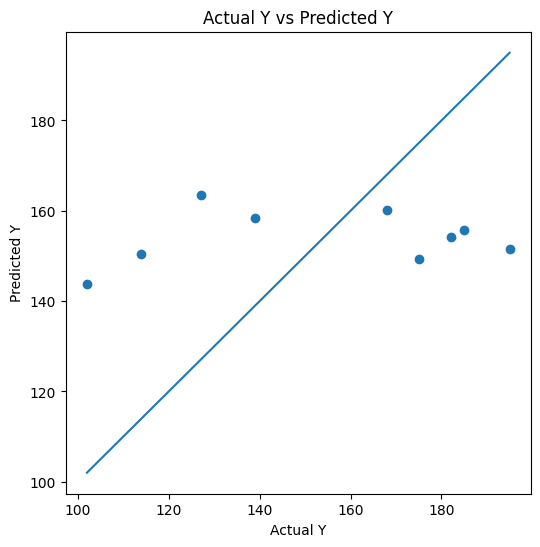

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(df['Y'], df['Y_pred'])
plt.xlabel("Actual Y")
plt.ylabel("Predicted Y")
plt.title("Actual Y vs Predicted Y")

# Reference diagonal line (perfect prediction)
min_y = min(df['Y'].min(), df['Y_pred'].min())
max_y = max(df['Y'].max(), df['Y_pred'].max())
plt.plot([min_y, max_y], [min_y, max_y])

plt.show()


Multiple Linear Regression for the csv



In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("student_exam_scores.csv")

X = df[['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores']]
Y = df['exam_score']

X.insert(0, 'bias', 1)

X = X.values
Y = Y.values.reshape(-1, 1)

# -------- NORMAL EQUATION --------
# theta = (XᵀX)^(-1) XᵀY
XT = X.T
theta = np.linalg.inv(XT.dot(X)).dot(XT).dot(Y)

# -------- PARAMETERS --------
c = theta[0][0]
m1, m2, m3, m4 = theta[1][0], theta[2][0], theta[3][0], theta[4][0]

print("Intercept (c):", c)
print("hours_studied coefficient:", m1)
print("sleep_hours coefficient:", m2)
print("attendance_percent coefficient:", m3)
print("previous_scores coefficient:", m4)

# -------- PREDICTION --------
Y_pred = X.dot(theta)

# -------- MSE & RMSE --------
errors = Y - Y_pred
MSE = np.mean(errors ** 2)
RMSE = np.sqrt(MSE)

print("\nMSE:", MSE)
print("RMSE:", RMSE)

# -------- TEST WITH NEW INPUT --------
print("\n--- Test with new student data ---")
hs = float(input("Hours studied: "))
sh = float(input("Sleep hours: "))
ap = float(input("Attendance percent: "))
ps = float(input("Previous score: "))

new_X = np.array([[1, hs, sh, ap, ps]])
predicted_score = new_X.dot(theta)

print("Predicted Exam Score:", predicted_score[0][0])



Intercept (c): -2.1420867991016355
hours_studied coefficient: 1.5552597274912103
sleep_hours coefficient: 0.9522578842901946
attendance_percent coefficient: 0.10838990209066979
previous_scores coefficient: 0.17728478008445217

MSE: 7.273480856128563
RMSE: 2.696939164335852

--- Test with new student data ---
Hours studied: 10
Sleep hours: 3
Attendance percent: 77
Previous score: 55
Predicted Exam Score: 34.3639694943075


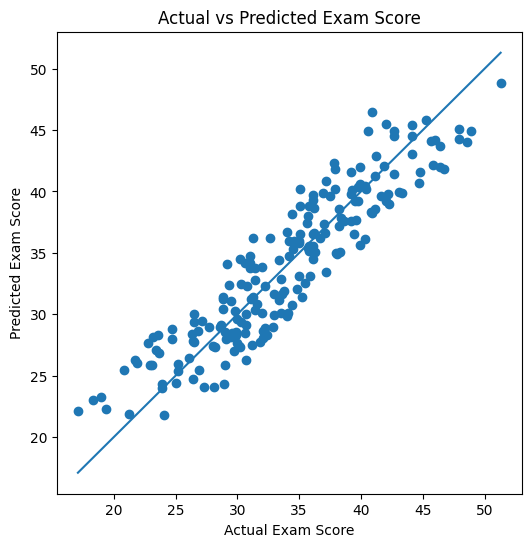

In [ ]:
import matplotlib.pyplot as plt

result_df = df.copy()
result_df['Predicted_exam_score'] = Y_pred.flatten()
result_df['Error'] = result_df['exam_score'] - result_df['Predicted_exam_score']
plt.figure(figsize=(6,6))
plt.scatter(result_df['exam_score'], result_df['Predicted_exam_score'])
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Score")

# reference line (ideal prediction)
min_val = result_df['exam_score'].min()
max_val = result_df['exam_score'].max()
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

